In [2]:
# Install dependencies (run once)
# !pip install xgboost scikit-learn pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

# Display settings
pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

print("✅ All libraries imported successfully!")
print(f"   XGBoost version : {xgb.__version__}")
print(f"   NumPy   version : {np.__version__}")
print(f"   Pandas  version : {pd.__version__}")


✅ All libraries imported successfully!
   XGBoost version : 3.2.0
   NumPy   version : 2.3.5
   Pandas  version : 2.3.3


In [3]:
data   = load_breast_cancer()
X      = pd.DataFrame(data.data, columns=data.feature_names)
y      = pd.Series(data.target, name="target")

print("📦 Dataset: Breast Cancer Wisconsin")
print(f"   Samples  : {X.shape[0]}")
print(f"   Features : {X.shape[1]}")
print(f"   Classes  : {list(data.target_names)}")
print()

📦 Dataset: Breast Cancer Wisconsin
   Samples  : 569
   Features : 30
   Classes  : [np.str_('malignant'), np.str_('benign')]



In [4]:
# Class distribution
counts = y.value_counts().rename(index={1: "Benign (1)", 0: "Malignant (0)"})
print("🔢 Class Distribution:")
print(counts.to_string())


🔢 Class Distribution:
target
Benign (1)       357
Malignant (0)    212


In [5]:
# First 5 rows
X.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
# Statistical summary
X.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.13,3.52,6.98,11.70,13.37,15.78,28.11
mean texture,569.0,19.29,4.30,9.71,16.17,18.84,21.80,39.28
mean perimeter,569.0,91.97,24.30,43.79,75.17,86.24,104.10,188.50
mean area,569.0,654.89,351.91,143.50,420.30,551.10,782.70,2501.00
mean smoothness,569.0,0.10,0.01,0.05,0.09,0.10,0.11,0.16
mean compactness,569.0,0.10,0.05,0.02,0.06,0.09,0.13,0.35
mean concavity,569.0,0.09,0.08,0.00,0.03,0.06,0.13,0.43
mean concave points,569.0,0.05,0.04,0.00,0.02,0.03,0.07,0.20
mean symmetry,569.0,0.18,0.03,0.11,0.16,0.18,0.20,0.30
mean fractal dimension,569.0,0.06,0.01,0.05,0.06,0.06,0.07,0.10


❓ Missing values: 0


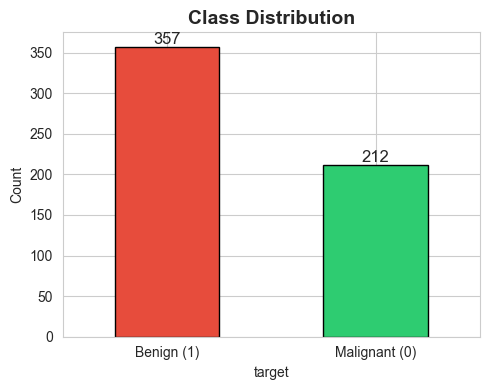

In [7]:
# Check for missing values
missing = X.isnull().sum().sum()
print(f"❓ Missing values: {missing}")

# Class distribution bar chart
fig, ax = plt.subplots(figsize=(5, 4))
counts.plot(kind="bar", color=["#e74c3c", "#2ecc71"], edgecolor="black", ax=ax)
ax.set_title("Class Distribution", fontsize=14, fontweight="bold")
ax.set_ylabel("Count")
ax.set_xticklabels(counts.index, rotation=0)
for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha="center", va="bottom", fontsize=12)
plt.tight_layout()
plt.show()
